In [1]:
import sys
from pathlib import Path
sys.path.append('..')

# Import the library
from src.cvh_cost import (
    CondoParams,
    HouseParams,
    SimulationParams,
    EconomicParams,
    EventConfig,
    RecurringOtherCost,
    compute_deterministic,
    run_monte_carlo,
    load_config,
    pv_to_monthly_savings,
)
from src.cvh_cost.reporting import (
    format_text_report, 
    plot_diff_distribution, 
    plot_pv_distributions,
    plot_sensitivity,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Path to examples folder
EXAMPLES_DIR = Path("../examples")

## 1. Loading Configuration from YAML

Instead of defining parameters in code, we can load them from YAML files.

**Understanding the Results:**
- All values are **Present Value (PV) of ownership costs** over the analysis period
- Higher PV = more expensive to own
- Monthly savings shows how much to set aside each month to cover those costs

In [2]:
# Load the advanced configuration
config_path = EXAMPLES_DIR / "advanced_config.yaml"
condo, house, sim, econ = load_config(str(config_path))

print("Configuration loaded successfully!")
print(f"\nCondo:")
print(f"  Monthly fee: ${condo.monthly_fee}")
print(f"  Fee escalation: {condo.fee_escalation_rate:.1%}")
print(f"  Events: {len(condo.events)}")
print(f"  Other recurring costs: {len(condo.other_recurring_costs)}")

print(f"\nHouse:")
print(f"  Initial value: ${house.initial_value:,}")
print(f"  Value growth: {house.value_growth_rate:.1%}")
print(f"  Maintenance rate: {house.annual_maintenance_rate:.1%}")
print(f"  Events: {len(house.events)}")
print(f"  Other recurring costs: {len(house.other_recurring_costs)}")

print(f"\nSimulation:")
print(f"  Years: {sim.years}")
print(f"  Discount rate: {sim.discount_rate:.1%}")
print(f"  Monte Carlo sims: {sim.num_sims:,}")

Configuration loaded successfully!

Condo:
  Monthly fee: $550.0
  Fee escalation: 3.0%
  Events: 2
  Other recurring costs: 2

House:
  Initial value: $500,000.0
  Value growth: 2.0%
  Maintenance rate: 1.5%
  Events: 6
  Other recurring costs: 3

Simulation:
  Years: 30
  Discount rate: 3.5%
  Monte Carlo sims: 20,000


In [3]:
# List all events
print("CONDO EVENTS:")
for e in condo.events:
    print(f"  - {e.name}: ${e.base_cost:,} in year {e.expected_year} (±{e.timing_std_years}y)")

print("\nHOUSE EVENTS:")
for e in house.events:
    print(f"  - {e.name}: ${e.base_cost:,} in year {e.expected_year} (±{e.timing_std_years}y)")

print("\nCONDO OTHER COSTS:")
for c in condo.other_recurring_costs:
    print(f"  - {c.name}: ${c.annual_amount:,}/year")

print("\nHOUSE OTHER COSTS:")
for c in house.other_recurring_costs:
    print(f"  - {c.name}: ${c.annual_amount:,}/year")

CONDO EVENTS:
  - special_assessment_exterior: $8,000.0 in year 10 (±2.0y)
  - special_assessment_amenities: $5,000.0 in year 18 (±2.0y)

HOUSE EVENTS:
  - roof_replacement: $10,000.0 in year 20 (±3.0y)
  - hvac_replacement: $5,000.0 in year 15 (±2.0y)
  - water_heater: $1,200.0 in year 12 (±2.0y)
  - appliance_refresh: $0.0 in year 10 (±1.0y)
  - exterior_paint: $500.0 in year 20 (±3.0y)
  - driveway_repair: $3,000.0 in year 30 (±3.0y)

CONDO OTHER COSTS:
  - unit_insurance: $600.0/year
  - parking_fee: $1,200.0/year

HOUSE OTHER COSTS:
  - home_insurance: $1,200.0/year
  - landscaping: $1,000.0/year
  - snow_removal: $350.0/year


## 2. Run Full Analysis

In [4]:
# Run both deterministic and Monte Carlo
det_result = compute_deterministic(condo, house, sim, econ)
mc_result = run_monte_carlo(condo, house, sim, econ)

# Print full report
report = format_text_report(det_result, mc_result, sim)
print(report)

CONDO VS HOUSE OWNERSHIP COST ANALYSIS

Analysis horizon: 30 years
Discount rate: 3.50%

Note: All values are Present Value (PV) of ownership costs.
      Higher PV = more expensive over the analysis period.

----------------------------------------
DETERMINISTIC RESULTS
----------------------------------------

Condo Ownership Costs (PV):
  Monthly fees:     $     183,843
  One-time events:  $       8,363
  Other recurring:  $      39,669
  TOTAL PV:         $     231,876
  → Equivalent monthly savings: $   1,041/mo

House Ownership Costs (PV):
  Maintenance:      $     177,325
  One-time events:  $      10,124
  Other recurring:  $      61,775
  TOTAL PV:         $     249,225
  → Equivalent monthly savings: $   1,119/mo

Cost Difference (House - Condo): $      17,349
  → House costs $17,349 more (PV)
  → You'd need ~$78/mo extra savings for house

----------------------------------------
MONTE CARLO RESULTS
----------------------------------------
Simulations: 20,000

Condo Ownershi

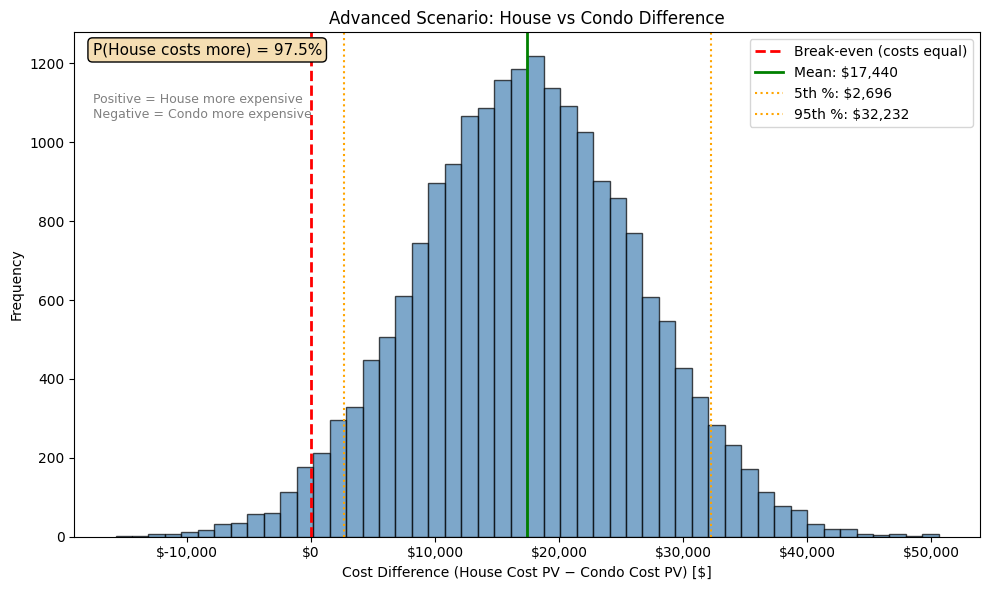

In [5]:
# Visualize the results
fig = plot_diff_distribution(mc_result, title="Advanced Scenario: House vs Condo Difference")
plt.show()

## 3. Multi-Scenario Comparison

Let's compare three scenarios: base, optimistic (lower house costs), and pessimistic (higher house costs).

In [6]:
# Define scenarios by modifying the house maintenance rate
scenarios = {
    "optimistic": 0.010,  # 1.0% maintenance
    "base": 0.015,        # 1.5% maintenance
    "pessimistic": 0.020, # 2.0% maintenance
}

results = {}

for name, maint_rate in scenarios.items():
    # Create modified house params
    house_mod = HouseParams(
        initial_value=house.initial_value,
        value_growth_rate=house.value_growth_rate,
        annual_maintenance_rate=maint_rate,
        events=house.events,
        other_recurring_costs=house.other_recurring_costs,
    )
    
    # Run Monte Carlo
    mc = run_monte_carlo(condo, house_mod, sim, econ)
    results[name] = mc
    
    # Calculate monthly savings difference
    diff_monthly = pv_to_monthly_savings(abs(mc.diff_summary.mean), sim.discount_rate, sim.years)
    
    print(f"{name.upper()} (maint={maint_rate:.1%}):")
    print(f"  Mean cost diff (PV): ${mc.diff_summary.mean:,.0f}")
    print(f"  Extra monthly for house: ~${diff_monthly:,.0f}/mo")
    print(f"  P(House costs more): {mc.prob_house_more_expensive:.1%}")
    print()

OPTIMISTIC (maint=1.0%):
  Mean cost diff (PV): $-41,691
  Extra monthly for house: ~$187/mo
  P(House costs more): 0.0%

BASE (maint=1.5%):
  Mean cost diff (PV): $17,440
  Extra monthly for house: ~$78/mo
  P(House costs more): 97.5%

BASE (maint=1.5%):
  Mean cost diff (PV): $17,440
  Extra monthly for house: ~$78/mo
  P(House costs more): 97.5%

PESSIMISTIC (maint=2.0%):
  Mean cost diff (PV): $76,572
  Extra monthly for house: ~$344/mo
  P(House costs more): 100.0%

PESSIMISTIC (maint=2.0%):
  Mean cost diff (PV): $76,572
  Extra monthly for house: ~$344/mo
  P(House costs more): 100.0%



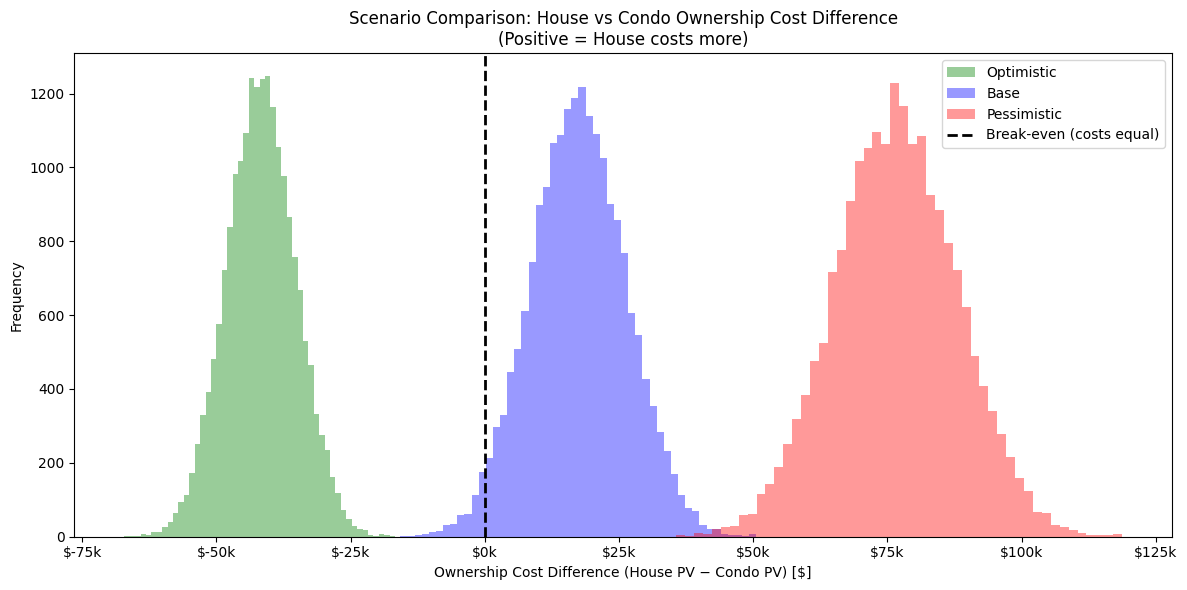

In [7]:
# Compare distributions
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'optimistic': 'green', 'base': 'blue', 'pessimistic': 'red'}

for name, mc in results.items():
    ax.hist(mc.diff_pv, bins=50, alpha=0.4, label=f"{name.capitalize()}", color=colors[name])

ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Break-even (costs equal)')
ax.set_xlabel('Ownership Cost Difference (House PV − Condo PV) [$]')
ax.set_ylabel('Frequency')
ax.set_title('Scenario Comparison: House vs Condo Ownership Cost Difference\n(Positive = House costs more)')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis

Let's see how the probability of house costing more changes as we vary key parameters.

Note: In this scenario, the house is substantially more expensive than the condo, so the probability stays at ~100% across different discount rates and horizons. This is expected behavior - it shows the conclusion is robust to these parameter choices.

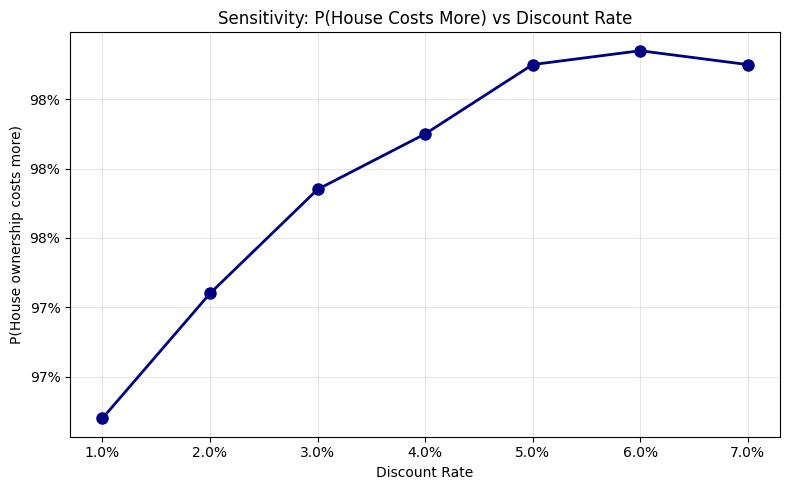

In [8]:
# Sensitivity to discount rate
discount_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
probs_by_rate = []

for rate in discount_rates:
    sim_mod = SimulationParams(
        years=sim.years,
        discount_rate=rate,
        num_sims=5000,  # Fewer sims for speed
        random_seed=sim.random_seed,
        house_maintenance_vol=sim.house_maintenance_vol,
        condo_fee_vol=sim.condo_fee_vol,
    )
    mc = run_monte_carlo(condo, house, sim_mod, econ)
    probs_by_rate.append(mc.prob_house_more_expensive)

# Plot
fig = plot_sensitivity(
    discount_rates, 
    probs_by_rate, 
    param_name="Discount Rate",
    title="Sensitivity: P(House Costs More) vs Discount Rate"
)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.show()

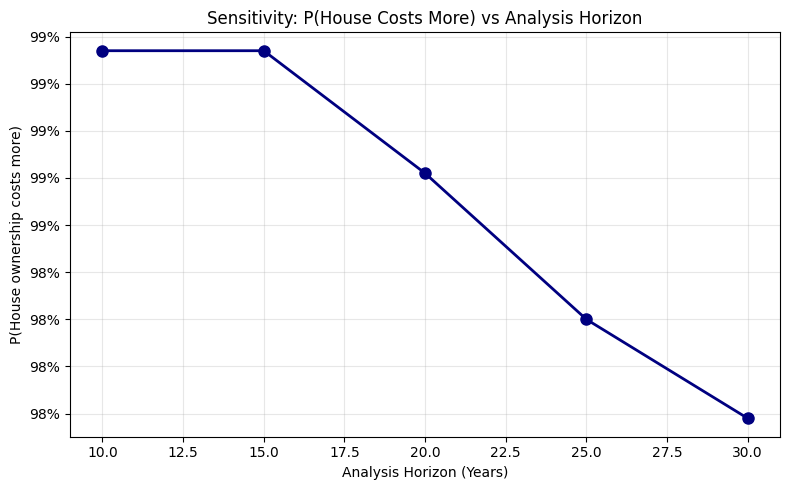

In [9]:
# Sensitivity to analysis horizon
year_values = [10, 15, 20, 25, 30]
probs_by_years = []

for years in year_values:
    sim_mod = SimulationParams(
        years=years,
        discount_rate=sim.discount_rate,
        num_sims=5000,
        random_seed=sim.random_seed,
        house_maintenance_vol=sim.house_maintenance_vol,
        condo_fee_vol=sim.condo_fee_vol,
    )
    mc = run_monte_carlo(condo, house, sim_mod, econ)
    probs_by_years.append(mc.prob_house_more_expensive)

# Plot
fig = plot_sensitivity(
    year_values, 
    probs_by_years, 
    param_name="Analysis Horizon (Years)",
    title="Sensitivity: P(House Costs More) vs Analysis Horizon"
)
plt.show()

## 5. Analyzing Event Timing

Let's examine how random event timing affects the ownership costs.

In [10]:
# Create a scenario with a single large event to isolate timing effects
house_single_event = HouseParams(
    initial_value=400_000,
    annual_maintenance_rate=0.01,  # Low maintenance
    events=[
        EventConfig(
            name="major_renovation",
            base_cost=30_000,
            expected_year=15,
            timing_std_years=4,  # Large timing uncertainty
            min_year=5,
            max_year=25,
            cost_vol=0.0,  # No cost uncertainty (isolate timing)
        ),
    ],
)

simple_condo = CondoParams(monthly_fee=300)

sim_timing = SimulationParams(
    years=25,
    discount_rate=0.04,
    num_sims=10_000,
    random_seed=123,
)

mc_timing = run_monte_carlo(simple_condo, house_single_event, sim_timing, econ)

# Calculate monthly equivalents
house_monthly = pv_to_monthly_savings(mc_timing.house_summary.mean, sim_timing.discount_rate, sim_timing.years)

print("Effect of timing uncertainty on a single $30k event:")
print(f"  Expected year: 15 (±4 years)")
print(f"\nHouse Ownership Cost PV:")
print(f"  Mean:  ${mc_timing.house_summary.mean:,.0f}  (~${house_monthly:,.0f}/mo)")
print(f"  Std:   ${mc_timing.house_summary.std:,.0f}")
print(f"  Range: [${mc_timing.house_summary.p5:,.0f}, ${mc_timing.house_summary.p95:,.0f}]")
print(f"\nThe timing uncertainty creates ~${mc_timing.house_summary.std:,.0f} PV variation")

Effect of timing uncertainty on a single $30k event:
  Expected year: 15 (±4 years)

House Ownership Cost PV:
  Mean:  $79,325  (~$419/mo)
  Std:   $2,628
  Range: [$75,147, $84,409]

The timing uncertainty creates ~$2,628 PV variation


## 6. Create Summary DataFrame

Let's create a summary with monthly savings equivalents.

In [11]:
# Create a comprehensive summary DataFrame
summary_data = []

for name, mc in results.items():
    condo_monthly = pv_to_monthly_savings(mc.condo_summary.mean, sim.discount_rate, sim.years)
    house_monthly = pv_to_monthly_savings(mc.house_summary.mean, sim.discount_rate, sim.years)
    diff_monthly = pv_to_monthly_savings(abs(mc.diff_summary.mean), sim.discount_rate, sim.years)
    
    summary_data.append({
        'Scenario': name.capitalize(),
        'Condo Cost PV': mc.condo_summary.mean,
        'Condo $/mo': condo_monthly,
        'House Cost PV': mc.house_summary.mean,
        'House $/mo': house_monthly,
        'Diff PV': mc.diff_summary.mean,
        'Extra $/mo': diff_monthly,
        'P(House>Condo)': mc.prob_house_more_expensive,
    })

summary_df = pd.DataFrame(summary_data)

# Format for display
display_df = summary_df.copy()
for col in ['Condo Cost PV', 'House Cost PV', 'Diff PV']:
    display_df[col] = display_df[col].apply(lambda x: f'${x:,.0f}')
for col in ['Condo $/mo', 'House $/mo', 'Extra $/mo']:
    display_df[col] = display_df[col].apply(lambda x: f'${x:,.0f}')
display_df['P(House>Condo)'] = display_df['P(House>Condo)'].apply(lambda x: f'{x:.1%}')

display_df

,Scenario,Condo Cost PV,Condo $/mo,House Cost PV,House $/mo,Diff PV,Extra $/mo,P(House>Condo)
0,Optimistic,"$231,917","$1,041","$190,226",$854,"$-41,691",$187,0.0%
1,Base,"$231,917","$1,041","$249,358","$1,120","$17,440",$78,97.5%
2,Pessimistic,"$231,917","$1,041","$308,489","$1,385","$76,572",$344,100.0%


## Summary

This notebook demonstrated:

1. **YAML Configuration**: Load complex scenarios from files
2. **Multi-scenario Analysis**: Compare optimistic/base/pessimistic cases
3. **Sensitivity Analysis**: See how results change with discount rate and horizon
4. **Event Timing**: Understand the impact of timing uncertainty
5. **Monthly Savings**: Translate PV costs into actionable monthly amounts

**Key Interpretation Notes:**
- All values are **Present Value (PV) of ownership costs** - higher = more expensive
- The **monthly savings** figure shows how much you'd need to set aside each month to cover those ownership costs over the analysis period
- **100% probability** means the house costs more in virtually all simulated scenarios - this is expected when there's a large cost difference between options
- The **break-even line at $0** shows where costs would be equal (House PV = Condo PV)